--- Data Loaded Successfully ---
Dataset shape: (150, 4)

=== Part A: PCA using Covariance Matrix ===
Explained Variance Ratio (PC1, PC2): [0.92461872 0.05306648]
Total variance explained by 2 components: 97.77%



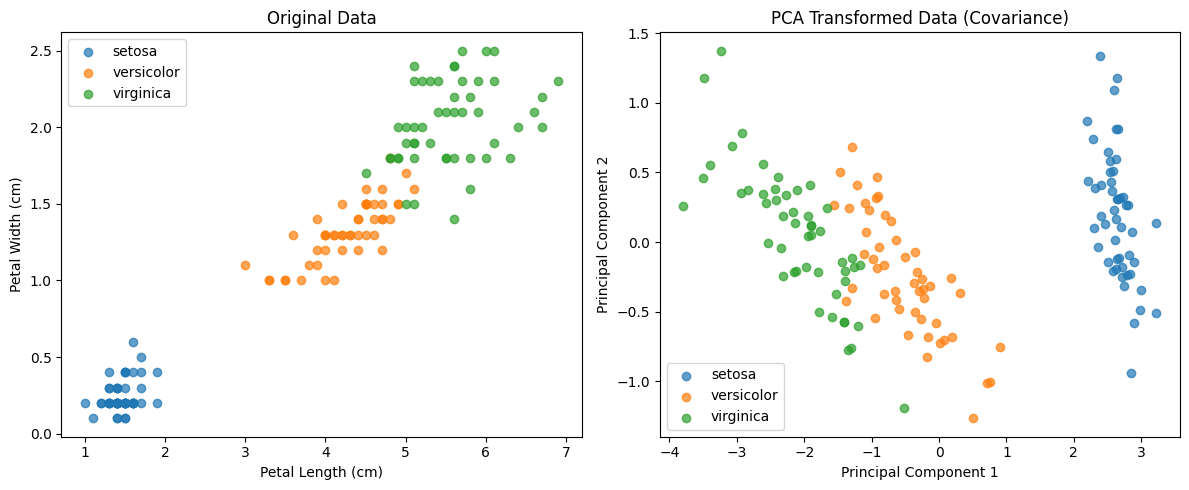

=== Part B: PCA using SVD and Comparison ===
Matrix U shape: (150, 4)
Singular values (Sigma): [25.09996044  6.01314738  3.41368064  1.88452351]
Matrix V^T shape: (4, 4)


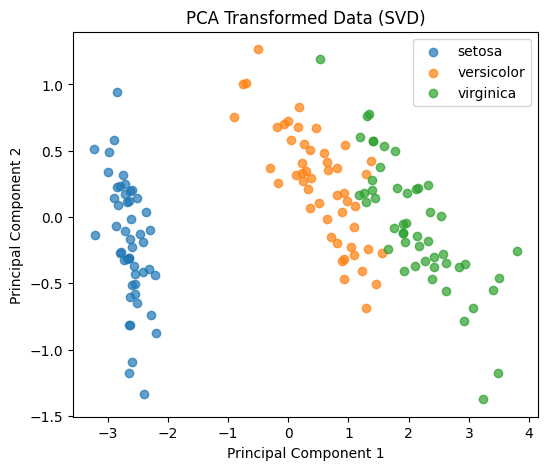

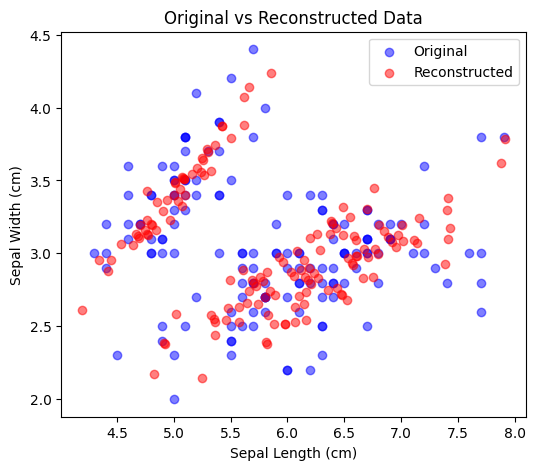

Reconstruction Error (Frobenius Norm): 3.8993

--- Comparison of PCA and SVD ---
Are the transformed results similar?
 Yes, they are essentially identical (ignoring possible sign flips).
Why do both methods give the same principal components?
Because the covariance matrix is proportional to X^T X. In SVD, X = U * Sigma * V^T,
so X^T X = (V * Sigma * U^T)(U * Sigma * V^T) = V * Sigma^2 * V^T.
This is the exact eigendecomposition of X^T X, meaning the right singular vectors (V) 
are exactly the eigenvectors of the covariance matrix.

=== Part C: K-Means Clustering from Scratch ===

--- Running K-Means (First 3 samples init) ---
Iteration 1:
  Centroids:
[[1.4 0.2]
 [1.4 0.2]
 [1.3 0.2]]
  Cluster sizes: [139  11]
Iteration 2:
  Centroids:
[[3.95755396 1.27625899]
 [1.4        0.2       ]
 [1.23636364 0.22727273]]
  Cluster sizes: [100  39  11]
Iteration 3:
  Centroids:
[[4.906      1.676     ]
 [1.52564103 0.25128205]
 [1.23636364 0.22727273]]
  Cluster sizes: [99 40 11]
Iteration 4:
  C

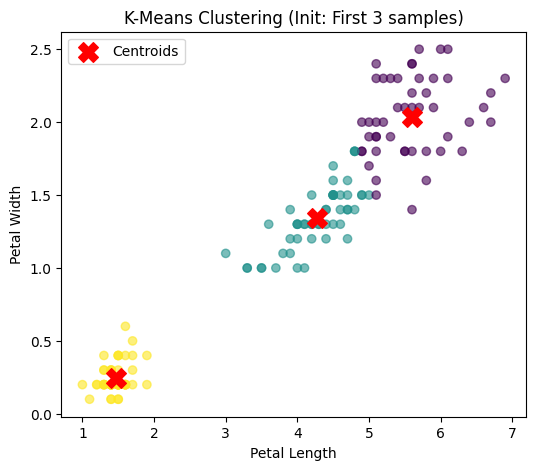


Final WCSS (Run 1): 31.3714
Note: K-Means labels are arbitrary and might not exactly match the original 0,1,2 numbering of the Iris target.

--- Running K-Means (Random initialization) ---
Iteration 1:
  Centroids:
[[4.7 1.2]
 [1.7 0.3]
 [6.9 2.3]]
  Cluster sizes: [78 51 21]
Iteration 2:
  Centroids:
[[4.62051282 1.54871795]
 [1.49215686 0.2627451 ]
 [6.05714286 2.17619048]]
  Cluster sizes: [68 50 32]
Iteration 3:
  Centroids:
[[4.45588235 1.475     ]
 [1.462      0.246     ]
 [5.8625     2.103125  ]]
  Cluster sizes: [63 50 37]
Iteration 4:
  Centroids:
[[4.4        1.42380952]
 [1.462      0.246     ]
 [5.76756757 2.10540541]]
  Cluster sizes: [59 50 41]
Iteration 5:
  Centroids:
[[4.35423729 1.39152542]
 [1.462      0.246     ]
 [5.7        2.08536585]]
  Cluster sizes: [56 50 44]
Iteration 6:
  Centroids:
[[4.31964286 1.36785714]
 [1.462      0.246     ]
 [5.65227273 2.06818182]]
  Cluster sizes: [55 50 45]
Iteration 7:
  Centroids:
[[4.30727273 1.36181818]
 [1.462      0.246   

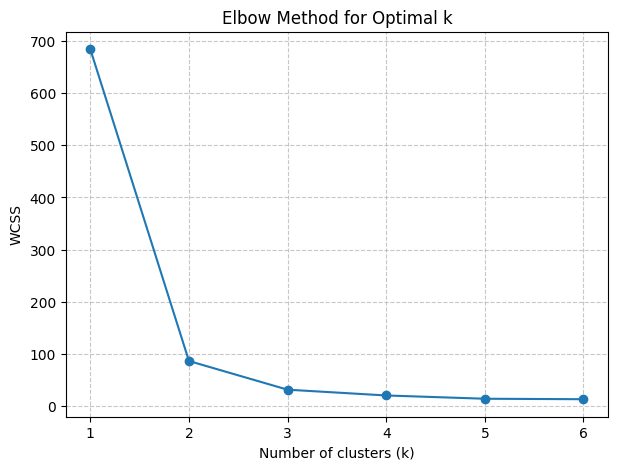

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_iris


iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print("--- Data Loaded Successfully ---")
print(f"Dataset shape: {X.shape}\n")

mean_vec = np.mean(X, axis=0)
Xc = X - mean_vec

n_samples = X.shape[0]
C = (Xc.T @ Xc) / (n_samples - 1)

eigenvalues, eigenvectors = np.linalg.eigh(C)

sorted_idx = np.argsort(eigenvalues)[::-1]
eigenvalues_sorted = eigenvalues[sorted_idx]
eigenvectors_sorted = eigenvectors[:, sorted_idx]

V2_cov = eigenvectors_sorted[:, :2]
X_pca_cov = Xc @ V2_cov

explained_variance_ratio = eigenvalues_sorted / np.sum(eigenvalues_sorted)
print(f"Explained Variance Ratio (PC1, PC2): {explained_variance_ratio[:2]}")
print(f"Total variance explained by 2 components: {np.sum(explained_variance_ratio[:2])*100:.2f}%\n")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, target_name in enumerate(target_names):
    axes[0].scatter(X[y == i, 2], X[y == i, 3], label=target_name, alpha=0.7)
axes[0].set_xlabel('Petal Length (cm)')
axes[0].set_ylabel('Petal Width (cm)')
axes[0].set_title('Original Data')
axes[0].legend()

for i, target_name in enumerate(target_names):
    axes[1].scatter(X_pca_cov[y == i, 0], X_pca_cov[y == i, 1], label=target_name, alpha=0.7)
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')
axes[1].set_title('PCA Transformed Data (Covariance)')
axes[1].legend()

plt.tight_layout()
plt.show()

U, S, Vt = np.linalg.svd(Xc, full_matrices=False)

print("Matrix U shape:", U.shape)
print("Singular values (Sigma):", S)
print("Matrix V^T shape:", Vt.shape)

V2_svd = Vt.T[:, :2]
Z = Xc @ V2_svd

plt.figure(figsize=(6, 5))
for i, target_name in enumerate(target_names):
    plt.scatter(Z[y == i, 0], Z[y == i, 1], label=target_name, alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Transformed Data (SVD)')
plt.legend()
plt.show()

X_approx_centered = Z @ V2_svd.T
X_approx = X_approx_centered + mean_vec

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], color='blue', alpha=0.5, label='Original')
plt.scatter(X_approx[:, 0], X_approx[:, 1], color='red', alpha=0.5, label='Reconstructed')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Original vs Reconstructed Data')
plt.legend()
plt.show()

reconstruction_error = np.linalg.norm(X - X_approx, ord='fro')
print(f"Reconstruction Error (Frobenius Norm): {reconstruction_error:.4f}\n")

print("--- Comparison of PCA and SVD ---")
print("Are the transformed results similar?\n Yes, they are essentially identical (ignoring possible sign flips).")
print("Why do both methods give the same principal components?")
print("Because the covariance matrix is proportional to X^T X. In SVD, X = U * Sigma * V^T,")
print("so X^T X = (V * Sigma * U^T)(U * Sigma * V^T) = V * Sigma^2 * V^T.")
print("This is the exact eigendecomposition of X^T X, meaning the right singular vectors (V) ")
print("are exactly the eigenvectors of the covariance matrix.\n")


print("=== Part C: K-Means Clustering from Scratch ===")

X_km = X[:, [2, 3]]

def run_kmeans(data, k, initial_centroids, max_iters=20):
    centroids = np.copy(initial_centroids)
    clusters = np.zeros(data.shape[0])

    for i in range(max_iters):
        distances = np.linalg.norm(data[:, np.newaxis] - centroids, axis=2)
        new_clusters = np.argmin(distances, axis=1)

        _, counts = np.unique(new_clusters, return_counts=True)
        print(f"Iteration {i+1}:")
        print(f"  Centroids:\n{centroids}")
        print(f"  Cluster sizes: {counts}")

        if np.array_equal(clusters, new_clusters):
            print("  -> Converged!")
            break

        clusters = new_clusters

        for j in range(k):
            if np.any(clusters == j):
                centroids[j] = np.mean(data[clusters == j], axis=0)

    wcss = 0
    for j in range(k):
        cluster_points = data[clusters == j]
        wcss += np.sum((cluster_points - centroids[j])**2)

    return clusters, centroids, wcss

print("\n--- Running K-Means (First 3 samples init) ---")
init_centroids_1 = X_km[:3]
clusters_1, centroids_1, wcss_1 = run_kmeans(X_km, k=3, initial_centroids=init_centroids_1)

plt.figure(figsize=(6, 5))
scatter = plt.scatter(X_km[:, 0], X_km[:, 1], c=clusters_1, cmap='viridis', alpha=0.6)
plt.scatter(centroids_1[:, 0], centroids_1[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('K-Means Clustering (Init: First 3 samples)')
plt.legend()
plt.show()

print(f"\nFinal WCSS (Run 1): {wcss_1:.4f}")
print("Note: K-Means labels are arbitrary and might not exactly match the original 0,1,2 numbering of the Iris target.")

print("\n--- Running K-Means (Random initialization) ---")
np.random.seed(42)
random_indices = np.random.choice(X_km.shape[0], 3, replace=False)
init_centroids_2 = X_km[random_indices]

clusters_2, centroids_2, wcss_2 = run_kmeans(X_km, k=3, initial_centroids=init_centroids_2)

print("\n--- Comparison of Initializations ---")
print("Final Centroids (Run 1):\n", centroids_1)
print("Final Centroids (Run 2):\n", centroids_2)
print(f"WCSS (Run 1): {wcss_1:.4f} | WCSS (Run 2): {wcss_2:.4f}")


print("\n=== Part D: Elbow Method for Optimal k ===")

wcss_list = []
K_values = list(range(1, 7))

for k in K_values:
    np.random.seed(42)
    init_idx = np.random.choice(X_km.shape[0], k, replace=False)
    init_c = X_km[init_idx]

    _, _, wcss_val = run_kmeans(X_km, k=k, initial_centroids=init_c, max_iters=30)
    wcss_list.append(wcss_val)

plt.figure(figsize=(7, 5))
plt.plot(K_values, wcss_list, marker='o', linestyle='-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal k')
plt.xticks(K_values)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
